## Import libraries

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

## Read csv

In [2]:
primary_df = pd.read_csv("dream.csv", usecols=list(range(1, 22)), header=0, names=["nick",
                                                                 "age",
                                                                 "sex", 
                                                                 "agreement", 
                                                                 "date",
                                                                 "fall_asleep",
                                                                 "wake_up", 
                                                                 "sleep_quality", 
                                                                 "awakenings", 
                                                                 "dream_remembered", 
                                                                 "dream_colored", 
                                                                 "amount_of_coffee", 
                                                                 "amount_of_coffee_after16",
                                                                 "alcohol",
                                                                 "strong_emotions",
                                                                 "stress_level",
                                                                 "hours_of_physical_activity",
                                                                 "daytime_sleep",
                                                                 "food_before_bed",
                                                                 "screen_time",
                                                                 "screen_before_bed",
                                                                 ])
primary_df.head(5)

,nick,age,sex,agreement,date,fall_asleep,wake_up,sleep_quality,awakenings,dream_remembered,...,amount_of_coffee,amount_of_coffee_after16,alcohol,strong_emotions,stress_level,hours_of_physical_activity,daytime_sleep,food_before_bed,screen_time,screen_before_bed
0,OLKA75,45 лет и более,Женский,Да,13.09.2026,23:30:00,6:45:00,3,3,Да,...,1,0,Да,Нет,4,2,Да,Нет,3,Да
1,Zverskiyponos67,до 18 лет,Женский,Да,13.09.2026,2:00:00,10:00:00,3,1,Нет,...,1,0,Нет,Нет,5,0,Нет,Нет,8,Нет
2,Kreeper,от 18 до 30 лет,Женский,Да,13.09.2026,0:00:00,8:13:00,4,0,Нет,...,0,0,Нет,Нет,2,4,Нет,Нет,8,Да
3,Tukiceja,45 лет и более,Мужской,Да,13.09.2026,23:00:00,6:20:00,3,3,Нет,...,1,0,Да,Нет,2,3,Да,Нет,3,Да
4,TihiyOmut,от 18 до 30 лет,Мужской,Да,13.09.2026,3:00:00,10:25:00,5,0,Да,...,10,4,Да,Да,2,1,Нет,Да,3,Да


Значение столбцов:
- id - ник пользователей
- age - возраст
- sex - пол
- agreement - соглашение на обработку персональных даных
- date - дата заполнения
- fall_asleep - время засыпания
- wake_up - время пробуждения
- sleep_quality - оценка качества сна (1-5)
- awakenings - количество пробуждений ночью (1-10)
- dream_remembered - запомнился ли сон (Да/Нет)
- dream_colored - цвет сна (Цветной/Чёрно-белый/Точно не могу сказать)
- amount_of_coffee - количество чашек кофе (0-10)
- amount_of_coffee_after16 - количество чашек кофе после 16 (0-10)
- alcohol - употребление алкоголя (Да/Нет)
- strong_emotions - сильные эмоции (Да/Нет)
- stress_level - уровень стресса (1-10)
- hours_of_physical_activity - часы физической активности (0-10)
- daytime_sleep - сон днём (Да/Нет)
- food_before_bed - еда перед сном (Да/Нет)
- screen_time - экранное время за день (0-10)
- screen_before_bed - экран перед сном (Да/Нет)

## General EDA

In [3]:
print(f"Размер dataframe: {primary_df.shape}")

Размер dataframe: (421, 21)


In [4]:
primary_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 421 entries, 0 to 420
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   nick                        421 non-null    str  
 1   age                         421 non-null    str  
 2   sex                         421 non-null    str  
 3   agreement                   421 non-null    str  
 4   date                        421 non-null    str  
 5   fall_asleep                 421 non-null    str  
 6   wake_up                     421 non-null    str  
 7   sleep_quality               421 non-null    int64
 8   awakenings                  421 non-null    int64
 9   dream_remembered            421 non-null    str  
 10  dream_colored               187 non-null    str  
 11  amount_of_coffee            421 non-null    int64
 12  amount_of_coffee_after16    421 non-null    int64
 13  alcohol                     421 non-null    str  
 14  strong_emotions      

In [5]:
df = primary_df.copy()

### Downcast features and conversion to categorical form

In [6]:
# Дата
df["date"] = pd.to_datetime(df["date"])

# Время
df["wake_up"] = pd.to_timedelta(df["wake_up"])
df["fall_asleep"] = pd.to_timedelta(df["fall_asleep"])

# Категориальные колонки
df["dream_colored"] = df["dream_colored"].map({"В основном цветное": "color", "В основном чёрно-белое": "black-white", "Точно не могу сказать": "not_defined"})
categorial_cols = ["dream_colored"]
df[categorial_cols] = df[categorial_cols].astype("category")

age_ordered = ["до 18 лет", "от 18 до 30 лет", "от 30 до 45  лет", "45 лет и более"]
df["age"] = pd.Categorical(df["age"], categories=age_ordered, ordered=True)

# Кодировка и преобразование в числовые
df["sex"] = df["sex"].map({"Мужской": 0, "Женский": 1})

binar_dict = {"Нет": 0, "Да": 1}
binary_cols = ["dream_remembered", "alcohol", "daytime_sleep", "food_before_bed", "strong_emotions", "screen_before_bed"]
for col in binary_cols:
    df[col] = df[col].map(binar_dict)
    
for col in df.columns:
    if "int" in str(df[col].dtype):
        df[col] = pd.to_numeric(df[col], downcast="integer")

C:\Users\Ilay\AppData\Local\Temp\ipykernel_33696\3377489478.py:2: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["date"] = pd.to_datetime(df["date"])


In [7]:
print("Пропусков после бинаризации:", df[binary_cols].isna().sum().sum())

Пропусков после бинаризации: 0


In [8]:
# Все значения столбца "agreement" содержат только ответ "Да"
df = df.drop(["agreement"], axis=1)

In [9]:
# info после обработки столбцов
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 421 entries, 0 to 420
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype          
---  ------                      --------------  -----          
 0   nick                        421 non-null    str            
 1   age                         421 non-null    category       
 2   sex                         421 non-null    int8           
 3   date                        421 non-null    datetime64[us] 
 4   fall_asleep                 421 non-null    timedelta64[us]
 5   wake_up                     421 non-null    timedelta64[us]
 6   sleep_quality               421 non-null    int8           
 7   awakenings                  421 non-null    int8           
 8   dream_remembered            421 non-null    int8           
 9   dream_colored               187 non-null    category       
 10  amount_of_coffee            421 non-null    int8           
 11  amount_of_coffee_after16    421 non-null    int8        

In [10]:
df.describe()

,sex,date,fall_asleep,wake_up,sleep_quality,awakenings,dream_remembered,amount_of_coffee,amount_of_coffee_after16,alcohol,strong_emotions,stress_level,hours_of_physical_activity,daytime_sleep,food_before_bed,screen_time,screen_before_bed
count,421.000000,421,421,421,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000
mean,0.646081,2026-09-18 15:30:21.377672,0 days 09:48:17.529691,0 days 07:51:21.092636,3.745843,1.268409,0.444181,0.790974,0.263658,0.097387,0.451306,3.634204,2.524941,0.128266,0.460808,5.529691,0.909739
min,0.000000,2026-09-13 00:00:00,0 days 00:00:00,0 days 00:09:00,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2026-09-16 00:00:00,0 days 01:00:00,0 days 06:30:00,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,0.000000,0.000000,3.000000,1.000000
50%,1.000000,2026-09-19 00:00:00,0 days 02:50:00,0 days 07:40:00,4.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,2.000000,0.000000,0.000000,5.000000,1.000000
75%,1.000000,2026-09-22 00:00:00,0 days 23:00:00,0 days 09:00:00,5.000000,2.000000,1.000000,1.000000,0.000000,0.000000,1.000000,5.000000,4.000000,0.000000,1.000000,8.000000,1.000000
max,1.000000,2026-09-26 00:00:00,0 days 23:59:00,0 days 16:12:00,5.000000,10.000000,1.000000,10.000000,4.000000,1.000000,1.000000,10.000000,10.000000,1.000000,1.000000,10.000000,1.000000
std,0.478753,NaN,0 days 10:23:36.991220,0 days 01:54:55.151073,1.068828,1.653762,0.497466,1.118679,0.568486,0.296837,0.498215,2.294749,1.997015,0.334784,0.499055,2.692529,0.286897


Невалидные данные отсутствуют. Среднее значение превышает медиану из-за наличия в столбце смещения в сторону больших значений

In [11]:
df.isna().sum()

nick                            0
age                             0
sex                             0
date                            0
fall_asleep                     0
wake_up                         0
sleep_quality                   0
awakenings                      0
dream_remembered                0
dream_colored                 234
amount_of_coffee                0
amount_of_coffee_after16        0
alcohol                         0
strong_emotions                 0
stress_level                    0
hours_of_physical_activity      0
daytime_sleep                   0
food_before_bed                 0
screen_time                     0
screen_before_bed               0
dtype: int64

In [12]:
without_dream = df[df["dream_remembered"]== 0]["dream_remembered"].count()
print(f"Количество ответов людей, не видивших сон: {without_dream}")

Количество ответов людей, не видивших сон: 234


Пропуски найдены только в столбце dream_colored: 233. Данные пропуски являются техническими, потому что в этот день пользователи не видели сна ночью

In [13]:
df.duplicated().sum()

np.int64(0)

Дупликатов не найдено

In [14]:
df.nunique()

nick                           53
age                             4
sex                             2
date                           14
fall_asleep                   117
wake_up                       118
sleep_quality                   5
awakenings                     11
dream_remembered                2
dream_colored                   3
amount_of_coffee                6
amount_of_coffee_after16        4
alcohol                         2
strong_emotions                 2
stress_level                   10
hours_of_physical_activity     10
daytime_sleep                   2
food_before_bed                 2
screen_time                    11
screen_before_bed               2
dtype: int64

### Analysis of users who completed the survey

In [15]:
df["nick"].unique()

<StringArray>
[          'OLKA75',  'Zverskiyponos67',          'Kreeper',
         'Tukiceja',        'TihiyOmut',         'aboba777',
      'SLEEP_LOVER',            'hewwa',            'Прага',
              'Оно',           'nejnej',         'krasotka',
            'FOX07',             'Leva',         'Удача777',
          '1515net',      'Птицадивная',       'nikita_pdf',
    'Enemyofdeath ',        'aquamana ',          'GRASS42',
          'Маркул ',       'Константин',           'Наташа',
              'son',    'Питер Паркер ',       'silverain ',
 'GangsterMarmilad',         'WH1teM4N',            'Настя',
          'Rinasvm',           'Deston',            'груша',
        'даринкинс',     'Enemyofdeath',               'N1',
           'Fit345',        'Tukiceja ',     'Питер Паркер',
         'aquamana',           'Маркул',     'Птицадивная ',
        'silverain',       'TihiyOmut ',          'Pandora',
        'WH1teM4N ',      'nikita_pdf ',       'Sunflower ',
        'S

Обнаружены ошибки с наличием пробелов в конце, начале и середине псевдонима

In [16]:
df["nick"] = df["nick"].str.replace(" ", "")
print(f"Количество уникальных пользователей: {df["nick"].nunique()}")

Количество уникальных пользователей: 38


In [17]:
# Очистим лишние пробелы и выведем сколько дней пользователи проходили опрос
person_day = df.groupby(by=["nick"]).size().reset_index(name='count')
person_day

,nick,count
0,1515net,12
1,Deston,4
2,Enemyofdeath,12
3,FOX07,12
4,Fit345,11
5,GRASS42,12
6,GangsterMarmilad,12
7,Kreeper,12
8,Leva,12
9,N1,7


In [18]:
print(f"Количество участников, проходивших опрос все 12 дней: {len(person_day[person_day["count"] >= 12])}")

Количество участников, проходивших опрос все 12 дней: 26


In [19]:
df["personality_id"] = df.groupby(by=["nick"])["nick"].transform("ngroup") + 1

In [20]:
df[["personality_id", "age"]].drop_duplicates()["age"].value_counts(normalize=True)

age
от 18 до 30 лет     0.692308
45 лет и более      0.205128
до 18 лет           0.076923
от 30 до 45  лет    0.025641
Name: proportion, dtype: float64

Возраст 69% в группе "от 18 до 30 лет", признак мало вариативен и почти константа

In [21]:
df[["personality_id", "sex"]].drop_duplicates()["sex"].value_counts(normalize=True)

sex
1    0.657895
0    0.342105
Name: proportion, dtype: float64

In [22]:
# Подсчёт продолжительности сна
def calc_sleep_hours(df):
    diff = df["wake_up"] - df["fall_asleep"]
    mask = diff < pd.Timedelta(0)
    diff.loc[mask] += pd.Timedelta(days=1)

    df["sleep_duration"] = diff
    df["sleep_hours"] = diff.dt.total_seconds() / 3600
    
    return df

df = calc_sleep_hours(df)

## Analysis of the target variable `dream_remembered` with each feature

In [23]:
df["dream_remembered"].value_counts(normalize=True)

dream_remembered
0    0.555819
1    0.444181
Name: proportion, dtype: float64

In [24]:
print("Доля запоминания сна у каждого пользоователя, %")
shape_remembered = (df.groupby(by="personality_id")["dream_remembered"].mean() * 100).sort_values()
shape_remembered

Доля запоминания сна у каждого пользоователя, %


personality_id
5      0.000000
12     0.000000
1     16.666667
21    16.666667
28    16.666667
38    16.666667
20    18.181818
19    25.000000
32    25.000000
2     25.000000
37    27.272727
22    27.272727
10    28.571429
34    33.333333
26    33.333333
15    37.500000
30    38.461538
9     41.666667
7     41.666667
3     41.666667
16    45.454545
6     50.000000
29    50.000000
18    50.000000
35    50.000000
14    54.545455
31    57.142857
13    57.142857
33    58.333333
36    63.636364
24    66.666667
23    66.666667
17    66.666667
8     66.666667
25    66.666667
27    66.666667
11    83.333333
4     91.666667
Name: dream_remembered, dtype: float64

In [25]:
print(f"Максимальный процент запоминания снов у пользователя: {shape_remembered.max().round(1)}%")
print(f"Минимальный процент запоминания снов у пользователя: {shape_remembered.min().round(1)}%")

Максимальный процент запоминания снов у пользователя: 91.7%
Минимальный процент запоминания снов у пользователя: 0.0%


In [26]:
df["dream_colored"].value_counts(normalize=True)

dream_colored
color          0.802139
not_defined    0.133690
black-white    0.064171
Name: proportion, dtype: float64

In [27]:
dream_color_for_ages = df.groupby(by="age")["dream_colored"].value_counts().reset_index(name="count")
pivot_dream_color = dream_color_for_ages.pivot(index="age", columns="dream_colored", values="count")
pivot_dream_color

dream_colored,black-white,color,not_defined
age,,,
до 18 лет,0,4,0
от 18 до 30 лет,2,112,11
от 30 до 45 лет,0,7,0
45 лет и более,10,27,14


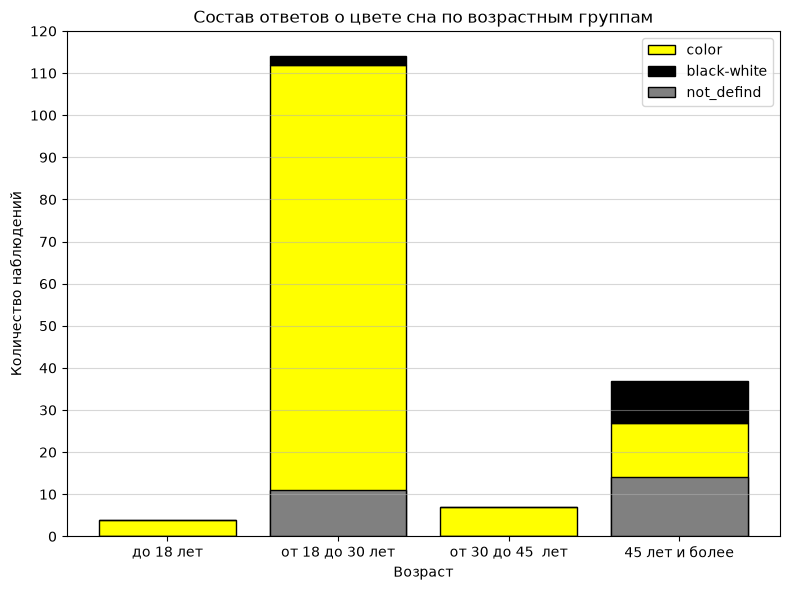

In [28]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.bar(pivot_dream_color.index, pivot_dream_color["color"], color="yellow", edgecolor="black")
ax.bar(pivot_dream_color.index, pivot_dream_color["black-white"], bottom=pivot_dream_color["color"], color="black", edgecolor="black")
ax.bar(pivot_dream_color.index, pivot_dream_color["not_defined"], color="gray", edgecolor="black")

ax.set_title("Cостав ответов о цвете сна по возрастным группам")
ax.set_xlabel("Возраст")
ax.set_ylabel("Количество наблюдений")

ax.set_yticks(range(0, 130, 10))

ax.grid(True, axis="y", alpha=0.5)

ax.legend(labels=["color", "black-white", "not_defind"])

plt.tight_layout()
plt.show()

Более 80% людей видят цветной сон, чёрно-белый сон в основном видят только люди возрастом более 45 лет (возможная причина - жизнь в период чёрно-белого телевидения/фотографии). Из-за небольшой выборки dream_colored сложно рассматривать как целевой признак

### Creating a boxplot for the target variable `dream_remembered` for all individuals.

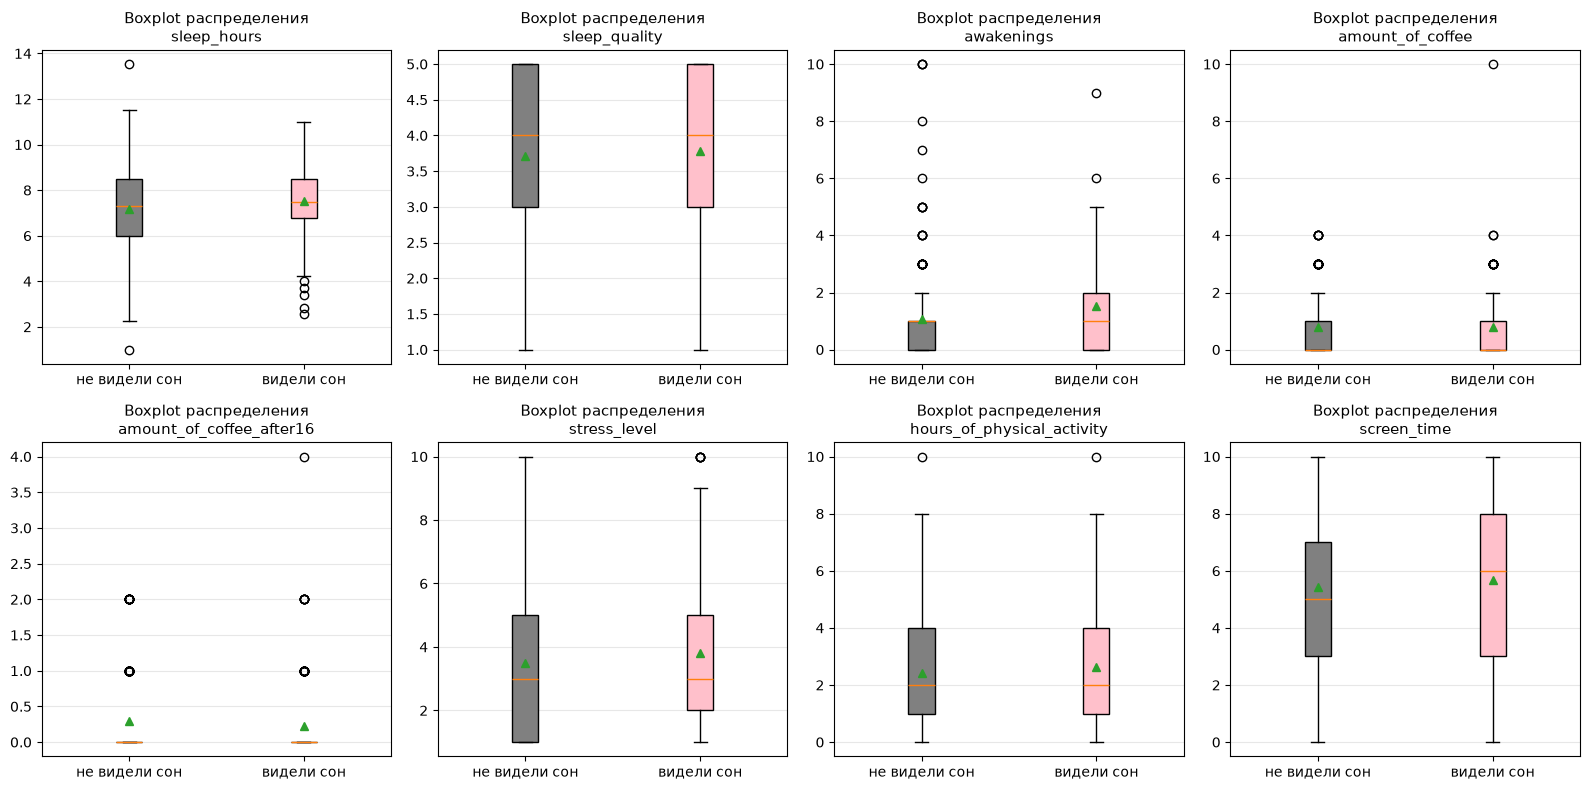

In [41]:
boxplot_cols = ['sleep_hours', 'sleep_quality', 'awakenings', 'amount_of_coffee', 'amount_of_coffee_after16', 'stress_level', 'hours_of_physical_activity', 'screen_time']

n = len(boxplot_cols)

fig, axes =  plt.subplots(2, (n + 1) // 2, figsize=(4 * ((n + 1) // 2), 8))

for ax, i in zip(axes.flatten(), boxplot_cols):

    group_0 = df[df["dream_remembered"] == 0][i].values
    group_1 = df[df["dream_remembered"] == 1][i].values

    bp = ax.boxplot([group_0, group_1], tick_labels=["не видели сон", "видели сон"], showmeans=True, patch_artist=True)

    ax.set_title(f"Boxplot распределения\n{i}", fontsize=11)

    ax.grid(True, alpha=0.3, axis="y")

    bp["boxes"][0].set_facecolor("gray")
    bp["boxes"][1].set_facecolor("pink")

plt.tight_layout()
plt.show()

- sleep hours: Медиана у видевших сон немного выше - примерно 7,5 часа против 7–7,2 часа. Есть выбросы около 21–23 часов; их стоит проверить в исходных данных.
- awakenings: У видевших и невидевших сон медиана около 1 пробуждения. Разброс большой, много выбросов сверху, у людей не видевших сон
- stress_level: Медиана в обеих группах около 3. У видевших сон среднее выглядит немного выше, но распределения существенно перекрываются.
- screen_time: Медиана у видевших сон около 6 часов, у не видевших — около 5. При этом разброс в обеих группах широк
- в графиках sleep_quality, amount_of_coffe(_after16), hours_of_physical_activity между видевшими и невидевшими сон различия близки к минимуму

### Emissions check in sleep_hours

In [30]:

Q3 = df["sleep_hours"].describe()["75%"]
Q1 = df["sleep_hours"].describe()["25%"]
IQR = Q3- Q1
emission_limit = Q3 + 1.5 * IQR

print(f"Граница верхних выбросов: {emission_limit}")

Граница верхних выбросов: 11.75


In [31]:
df[df["sleep_hours"] > emission_limit][["personality_id", "fall_asleep", "wake_up", "sleep_hours"]]

,personality_id,fall_asleep,wake_up,sleep_hours
16,35,0 days 10:30:00,0 days 07:30:00,21.000000
39,35,0 days 10:25:00,0 days 07:26:00,21.016667
53,33,0 days 12:00:00,0 days 10:00:00,22.000000
230,3,0 days 00:55:00,0 days 00:09:00,23.233333
358,16,0 days 21:00:00,0 days 10:32:00,13.533333


- В первых 3-х записях - ошибка записи формата времени (12 часовой вместо 24 часового формата)
- В 4 записи некорректно отмечено время подъёма - (вместо 09:00 00:09)
- В последней записи выброс является корректным

In [32]:
# Исправление первых 3-х наблюдений
hour = df["fall_asleep"].dt.components["hours"]
mask = (hour >= 6) & (hour < 14) & (df["daytime_sleep"] == 0)

df.loc[mask, "fall_asleep"] += pd.Timedelta(hours=12)

df.loc[hour == 12, "fall_asleep"] -= pd.Timedelta(hours=12)

In [33]:
# Исправление 4 наблюдения
idx_type = [91]
df.loc[230, "wake_up"] = pd.to_timedelta("09:00:00")

In [34]:
df = calc_sleep_hours(df)

### Creating a barchart for the target variable `dream_remembered` for all individuals.

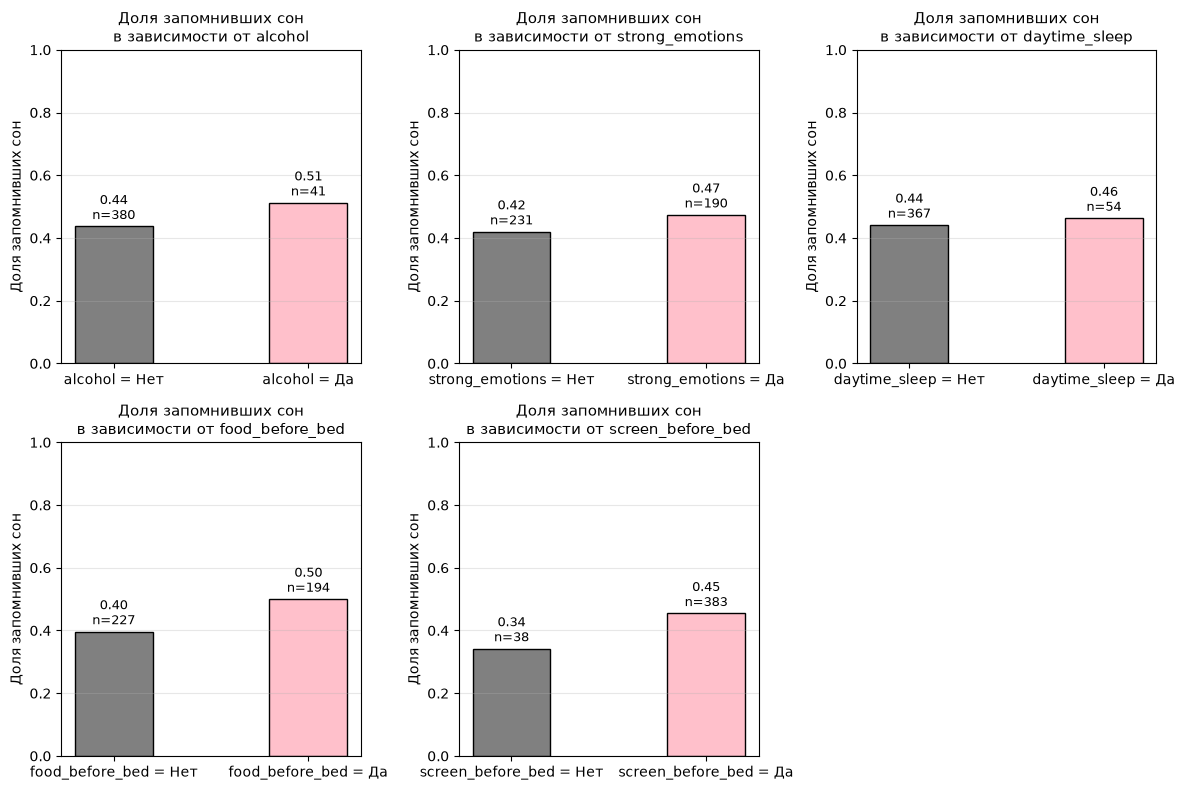

In [35]:
barchart_cols = ["alcohol", "strong_emotions", "daytime_sleep", "food_before_bed", "screen_before_bed"]
n = len(barchart_cols)

fig, axes = plt.subplots(2, (n + 1) // 2, figsize=(4 * ((n + 1) // 2), 8))

for ax, col in zip(axes.flatten(), barchart_cols):
    grouped = df.groupby(col)["dream_remembered"].agg(["mean", "count"])

    labels = [f"{col} = Нет", f"{col} = Да"]

    bars = ax.bar(labels, grouped["mean"], color=["gray", "pink"], width=0.4, edgecolor="black")

    for bar, mean_val, count_val in zip(bars, grouped["mean"], grouped["count"]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f"{mean_val:.2f}\nn={count_val}",
                ha="center", va="bottom", fontsize=9)

    ax.set_title(f"Доля запомнивших сон\nв зависимости от {col}", fontsize=11)
    ax.set_ylabel("Доля запомнивших сон")
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3, axis="y")

for ax in axes.flatten()[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

- alcohol: Доля несколько выше среди видевших сон
- strong_emotions: Разница незначительная
- daytime_sleep: Практически одинаковые доли
- food_before_bed: Разница около 10 процентных пунктов — одна из наиболее заметных на этих графиках
- screen_before_bed: Разница около 11 процентных пунктов — также одна из наиболее заметных

## Create a correlation matrix

In [36]:
num_cols = df.select_dtypes(include=[np.number], exclude=[np.timedelta64])
num_cols = num_cols.drop("personality_id", axis=1)

In [37]:
corr_matrix = num_cols.corr()

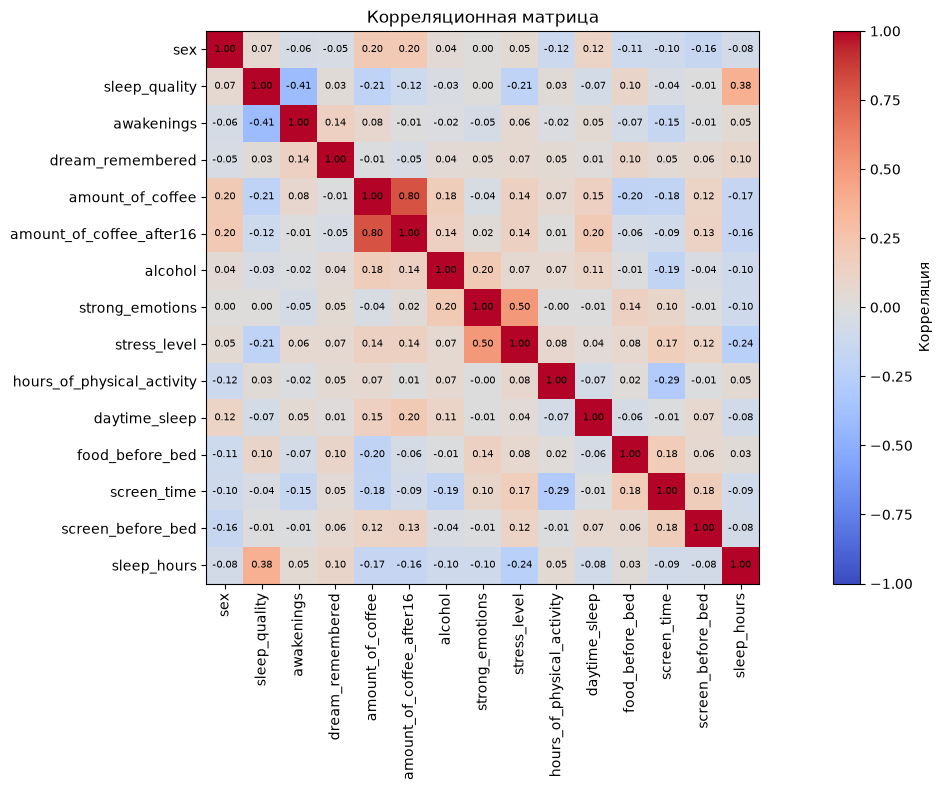

In [38]:
fig, ax = plt.subplots(figsize=(15, 8))

im = ax.imshow(corr_matrix, vmin=-1, vmax=1, cmap="coolwarm")

ax.set_title("Корреляционная матрица")
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_yticklabels(corr_matrix.columns, fontsize=10, rotation=0)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, fontsize=10, rotation=90)

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        ax.text(j, i, f"{val:.2f}",  ha="center", va="center", fontsize=7)

fig.colorbar(im, ax=ax, label="Корреляция")

plt.tight_layout()
plt.show()

В рассматриваемых числовых признаках не наблюдается заметной линейной ассоциации с таргетом. Это не исключает нелинейные зависимости, взаимодействия или влияние участника.

## Panel EDA